# TimesFM-2.5 Benchmarking

| | |
|---|---|
| **Organization** | Google Research |
| **Version** | TimesFM-2.5 (September 2025) |
| **Parameters** | 200M |
| **Input Features** | Target series only (covariates available via external XReg wrapper, but requires JAX) |

## Key Characteristics

TimesFM follows a decoder-only transformer design in which non-overlapping patches of time series data are treated as tokens and processed autoregressively. The model was pretrained on approximately 100 billion real-world time series observations, including Google Trends and Wikipedia pageview data, supplemented by synthetic and augmented series.

Version 2.5 reduces the parameter count from 500M (v2.0) to 200M while extending the maximum context length from 2,048 to 16,384 time steps and introducing natively calibrated quantile outputs. At time of release, TimesFM-2.5 ranked first among zero-shot foundation models on the GIFT-Eval leaderboard by both MASE and CRPS.

---

**Validation split:** Train on periods 1–36, validate on 37–42 (identical to Notebook 6)  
**Target:** `Revenue cons. (anon)` at subsegment level  
**Runtime:** T4 GPU (Google Colab) — set manually: Runtime → Change runtime type → T4 GPU

---
## 1. Dependencies

In [1]:
!pip install -q --upgrade transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 99.2 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 637.4/637.4 kB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 128.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 116.5 MB/s eta 0:00:0000:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
chronos-forecasting 2.2.2 requires transformers<5,>=4.41, but you have transformers 5.5.0 which is incompatible.
granite-tsfm 0.3.2.dev37+g640f7c80a requires transformers[torch]<4.51,>=4.38.0, but you have transformers 5.5.0 which is incompatible.


In [2]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print(f'GPU available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'Device: {torch.cuda.get_device_name(0)}')

GPU available: True
Device: Tesla T4


---
## 2. Configuration

In [3]:
# ── Constants ──
PERIOD_COL = 'Anon Period'
TARGET     = 'Revenue cons. (anon)'
SUBSEG_COL = 'TGL Business Subsegment'
VAL_CUTOFF = 36
HORIZON    = 6

# ── Paths ──
DATA_PATH  = '/content/drive/MyDrive/Coding/data/features/training_subsegment_fs.parquet'
VAL_PATH   = '/content/drive/MyDrive/Coding/data/features/validation_subsegment_fs.parquet'
OUTPUT_DIR = Path('/content/drive/MyDrive/Coding/data/predictions/')

---
## 3. Data & Function Loading

In [4]:
import sys
from google.colab import drive

drive.mount('/content/drive')

sys.path.insert(0, '/content/drive/MyDrive/Coding/functions/')
from pipeline_functions import *

# ── Load training data & split ──
full_train = pd.read_parquet(DATA_PATH)
train_df   = full_train[full_train[PERIOD_COL] <= VAL_CUTOFF].copy()
val_df     = full_train[full_train[PERIOD_COL] >  VAL_CUTOFF].copy()

print(f'Full train:    {full_train.shape}')
print(f'Train (1–36):  {train_df.shape}')
print(f'Val   (37–42): {val_df.shape}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Full train:    (4237, 110)
Train (1–36):  (3524, 110)
Val   (37–42): (713, 110)


In [5]:
# TimesFM does not support covariates — only the target series is used as input.

# ── Subsegments ──
subsegments = sorted(
    train_df.dropna(subset=[TARGET])
    .groupby(SUBSEG_COL, observed=True)
    .size()
    .pipe(lambda s: s[s >= 2].index)
    .tolist()
)
print(f'Subsegments: {len(subsegments)}')

# ── Results tracker ──
all_metrics = []

Subsegments: 117


---
## 4. Model Loading

In [6]:
from transformers import TimesFm2_5ModelForPrediction

device = 'cuda' if torch.cuda.is_available() else 'cpu'

tfm_model = TimesFm2_5ModelForPrediction.from_pretrained(
    'google/timesfm-2.5-200m-transformers',
)
tfm_model = tfm_model.to(torch.float32).to(device).eval()

print(f'TimesFM-2.5 loaded on {device}.')

config.json:   0%|          | 0.00/914 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/925M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

TimesFM-2.5 loaded on cuda.


---
## 5. Validation Forecasting (Periods 37–42)

In [7]:
# ── Build validation contexts ──
PATCH_SIZE = 32  # TimesFM internal patch size — input length must be a multiple

val_tensors, val_segs, val_skipped = [], [], []

for seg in subsegments:
    train_s = (train_df[train_df[SUBSEG_COL] == seg]
               .sort_values(PERIOD_COL)
               .dropna(subset=[TARGET]))
    val_s = (val_df[val_df[SUBSEG_COL] == seg]
             .sort_values(PERIOD_COL)
             .dropna(subset=[TARGET]))
    if len(train_s) < 4 or len(val_s) == 0:
        val_skipped.append(seg)
        continue
    series = train_s[TARGET].values.astype(float)
    # Pad front to nearest multiple of PATCH_SIZE
    padded_len = ((len(series) + PATCH_SIZE - 1) // PATCH_SIZE) * PATCH_SIZE
    if padded_len > len(series):
        series = np.concatenate([np.full(padded_len - len(series), series[0]), series])
    val_tensors.append(torch.tensor(series, dtype=torch.float32))
    val_segs.append(seg)

print(f'Contexts built: {len(val_tensors)} | Skipped: {len(val_skipped)}')
if val_skipped:
    print('Skipped:', val_skipped)

Contexts built: 107 | Skipped: 10
Skipped: ['SSI02710', 'SSI0278604', 'SSI0278624', 'SSI02796', 'SSI02798', 'SSI02799', 'SSI04783', 'SSI0478499', 'SSI07098', 'SSI07099']


In [8]:
# ── Batch predict — validation (single GPU call) ──
tfm_results, tfm_errors = {}, []

max_padded_len = max(len(t) for t in val_tensors)

try:
    with torch.no_grad():
        outputs = tfm_model(
            past_values=[t.to(device) for t in val_tensors],
            forecast_context_len=max_padded_len,
        )
    tfm_results = {
        seg: outputs.mean_predictions[i, :HORIZON].cpu().numpy()
        for i, seg in enumerate(val_segs)
    }
except Exception as e:
    tfm_errors.append(str(e))

print(f'Results: {len(tfm_results)}/{len(subsegments)} | Errors: {len(tfm_errors)}')
if tfm_errors:
    print('Errors:', tfm_errors)

Results: 107/117 | Errors: 0


In [9]:
metrics_tfm = evaluate(tfm_results, 'TimesFM-2.5', val_df, SUBSEG_COL, PERIOD_COL, TARGET)
all_metrics.append(metrics_tfm)

TimesFM-2.5 — RMSE: 9,182,431 | wMAPE: 11.4% | R²: 0.9819


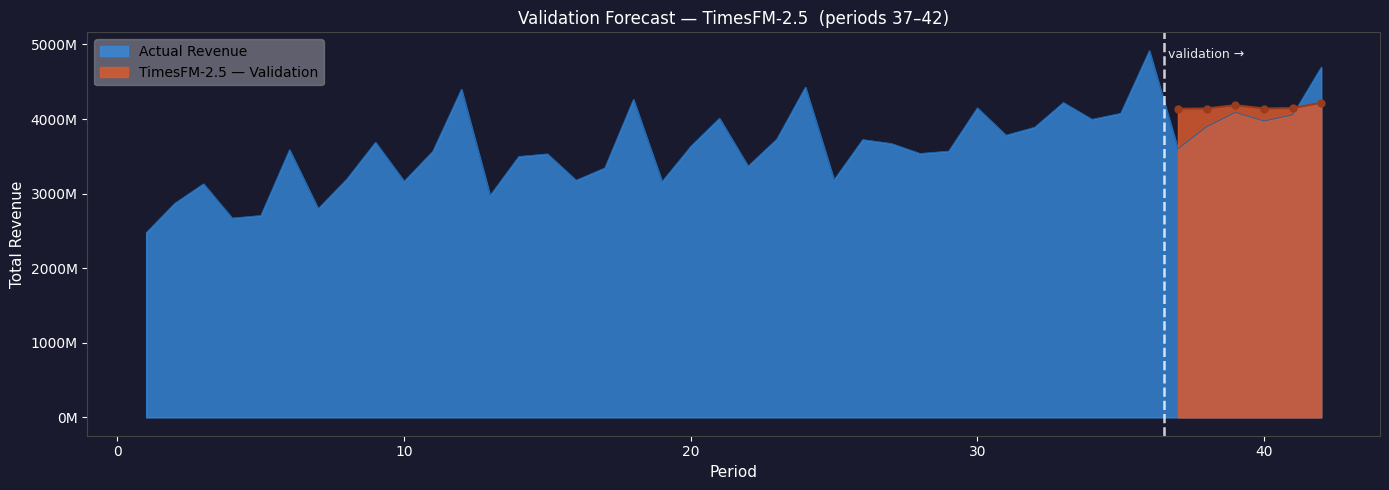

In [10]:
# ── Aggregate predictions by period & plot ──
agg_preds = {}
for t in range(HORIZON):
    period = VAL_CUTOFF + 1 + t   # 37 … 42
    agg_preds[period] = sum(
        preds[t] for preds in tfm_results.values() if len(preds) > t
    )

plot_forecast_area(full_train, agg_preds, 'TimesFM-2.5', TARGET, PERIOD_COL)

---
## 6. Blind Forecast (Periods 43–48)

In [11]:
# ── Load hold-out set ──
val_blind = pd.read_parquet(VAL_PATH)
TEST_CUTOFF = full_train[PERIOD_COL].max()  # = 42
test_subsegments = sorted(val_blind[SUBSEG_COL].unique())
print(f'Hold-out set: {val_blind.shape} | Subsegments: {len(test_subsegments)} | Test cutoff: {TEST_CUTOFF}')

Hold-out set: (715, 110) | Subsegments: 124 | Test cutoff: 42


In [12]:
# ── Build test contexts ──
test_tensors, test_segs, test_skipped = [], [], []

for seg in test_subsegments:
    train_s = (full_train[full_train[SUBSEG_COL] == seg]
               .sort_values(PERIOD_COL)
               .dropna(subset=[TARGET]))
    if len(train_s) < 4:
        test_skipped.append(seg)
        continue
    series = train_s[TARGET].values.astype(float)
    # Pad front to nearest multiple of PATCH_SIZE
    padded_len = ((len(series) + PATCH_SIZE - 1) // PATCH_SIZE) * PATCH_SIZE
    if padded_len > len(series):
        series = np.concatenate([np.full(padded_len - len(series), series[0]), series])
    test_tensors.append(torch.tensor(series, dtype=torch.float32))
    test_segs.append(seg)

print(f'Contexts built: {len(test_tensors)} | Skipped: {len(test_skipped)}')
if test_skipped:
    print('Skipped:', test_skipped)

Contexts built: 122 | Skipped: 2
Skipped: ['SSI0278218', 'SSI0278468']


In [13]:
# ── Batch predict — test (single GPU call) ──
tfm_test_results, tfm_test_errors = {}, []

test_max_padded_len = max(len(t) for t in test_tensors)

try:
    with torch.no_grad():
        test_outputs = tfm_model(
            past_values=[t.to(device) for t in test_tensors],
            forecast_context_len=test_max_padded_len,
        )
    tfm_test_results = {
        seg: test_outputs.mean_predictions[i, :HORIZON].cpu().numpy()
        for i, seg in enumerate(test_segs)
    }
except Exception as e:
    tfm_test_errors.append(str(e))

print(f'Results: {len(tfm_test_results)} | Skipped: {len(test_skipped)}')
if tfm_test_errors:
    print('Errors:', tfm_test_errors)

Results: 122 | Skipped: 2


In [14]:
# ── Build submission DataFrame ──
rows = [
    {SUBSEG_COL: seg, PERIOD_COL: TEST_CUTOFF + 1 + t, 'Revenue_Predicted': float(p)}
    for seg, preds in tfm_test_results.items()
    for t, p in enumerate(preds)
]
submission_df = (
    pd.DataFrame(rows)
    .merge(val_blind[[SUBSEG_COL, PERIOD_COL]], on=[SUBSEG_COL, PERIOD_COL], how='inner')
    .reset_index(drop=True)
)
print(f'Submission rows: {len(submission_df)}')  # Expected: 711
submission_df

Submission rows: 711


,TGL Business Subsegment,Anon Period,Revenue_Predicted
0,SSI02710,44,2.442609e+03
1,SSI02710,45,9.965469e+02
2,SSI02710,48,3.712500e+03
3,SSI0271002,43,1.233851e+06
4,SSI0271002,44,1.035175e+06
...,...,...,...
706,SSI0708310,44,7.733062e+06
707,SSI0708310,45,7.528076e+06
708,SSI0708310,46,7.477262e+06
709,SSI0708310,47,7.352014e+06


SSI0278218 appears 3× in the validation set but not in the training set.  
SSI0278468 appears 1× in the validation set but not in the training set.

Both IDs are therefore excluded from the final prediction.

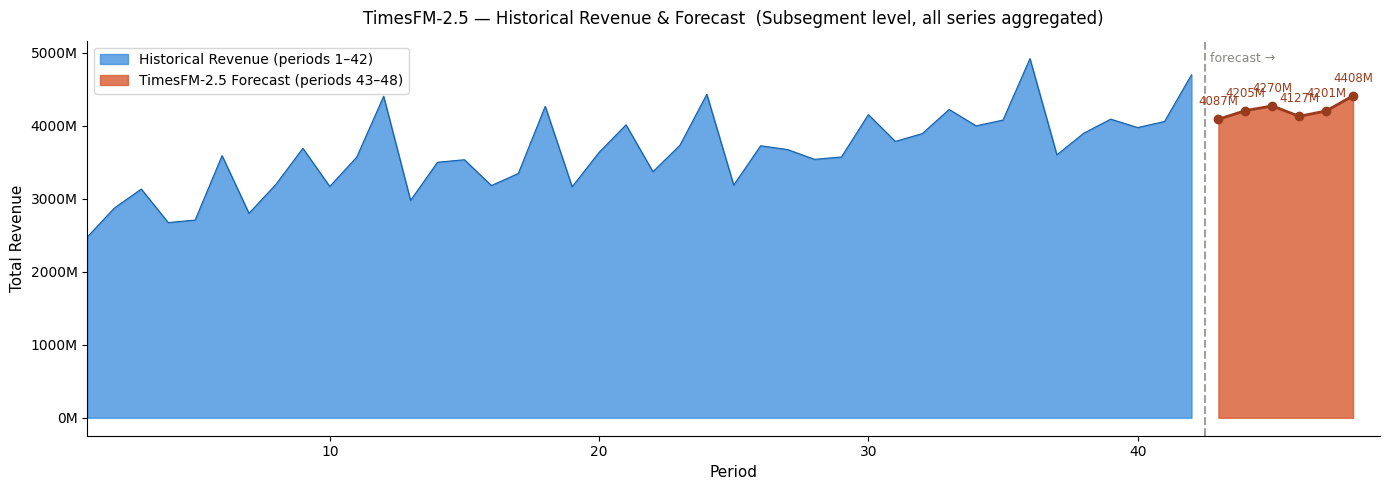

PosixPath('/content/drive/MyDrive/Coding/data/predictions/forecast_plot_timesfm-2.5.png')

In [15]:
# ── Plot blind forecast ──
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plot_forecast_comparison(
    train_df=full_train,
    submission_df=submission_df,
    period_col=PERIOD_COL,
    target_col=TARGET,
    best_model_name='TimesFM-2.5',
    output_dir=OUTPUT_DIR,
)